# 14 — Visualize Facilities and Campuses

## Research purpose

Map the geographical coverage and provider composition of the accepted facility and campus inventories.


## Imports

Load the libraries used to read the facility and campus tables, verify the boundary archive and draw the maps.


In [1]:
from pathlib import Path
import hashlib

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import requests
from IPython.display import display
from matplotlib.lines import Line2D

## Project paths

Locate the project root and define the paths for the facility and campus tables, world boundaries and saved maps.


In [ ]:
PROJECT_ROOT = Path.cwd().resolve()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if not (PROJECT_ROOT / "notebooks").is_dir() or not (PROJECT_ROOT / "data").is_dir():
    raise RuntimeError("Launch Jupyter from the folder containing data/ and notebooks/, or from its notebooks/ directory.")

FACILITY_INPUT = PROJECT_ROOT / "data/final/hyperscale_facilities_analysis.csv"
CAMPUS_INPUT = PROJECT_ROOT / "data/final/hyperscale_campuses_analysis.csv"
VISUALIZATION_DIR = PROJECT_ROOT / "visualizations"
NATURAL_EARTH_ZIP = PROJECT_ROOT / "data/raw/maps/ne_110m_admin_0_countries.zip"

## Map settings

Use Natural Earth release 5.1.2 and set consistent provider colours, map boundaries and marker sizes. Markers use constant sizes and do not encode capacity.


In [3]:
NATURAL_EARTH_URL = "https://naturalearth.s3.amazonaws.com/5.1.2/110m_cultural/ne_110m_admin_0_countries.zip"
NATURAL_EARTH_SHA256 = "0f243aeac8ac6cf26f0417285b0bd33ac47f1b5bdb719fd3e0df37d03ea37110"
PROVIDER_COLORS = {"Amazon": "#ff9900", "Google": "#4285f4", "Microsoft": "#7fba00"}
MAP_EXTENT = (-180, 180, -58, 85)
FACILITY_MARKER_SIZE = 18
CAMPUS_MARKER_SIZE = 22

## Map validation function

Define a function to check unique identifiers, provider names and coordinate ranges before plotting. Invalid records raise an error so that every supplied facility and campus remains accounted for.


In [4]:
def prepare_static_map_points(frame, *, id_column, providers):
    """Return numeric map coordinates while retaining every supplied row."""
    required = {id_column, "operator_group", "lat", "lon"}
    missing = required - set(frame.columns)
    if missing:
        raise ValueError(f"Map input is missing required columns: {sorted(missing)}")
    if frame[id_column].isna().any() or frame[id_column].duplicated().any():
        raise ValueError(f"Map input requires non-null, unique {id_column} values.")
    invalid_providers = ~frame["operator_group"].isin(providers)
    if invalid_providers.any():
        raise ValueError(f"Map input contains out-of-scope providers for IDs: {frame.loc[invalid_providers, id_column].tolist()}")
    points = frame.copy()
    points["lat"] = pd.to_numeric(points["lat"], errors="coerce")
    points["lon"] = pd.to_numeric(points["lon"], errors="coerce")
    invalid_coordinates = ~points["lat"].between(-90, 90) | ~points["lon"].between(-180, 180)
    if invalid_coordinates.any():
        raise ValueError(f"Map input contains unusable coordinates for IDs: {points.loc[invalid_coordinates, id_column].tolist()}")
    return points

## Load facility and campus locations

Read the completed facility and campus tables and validate the identifiers, providers and coordinates in each table.


In [5]:
facilities = pd.read_csv(FACILITY_INPUT)
campuses = pd.read_csv(CAMPUS_INPUT)
facility_points = prepare_static_map_points(
    facilities, id_column="facility_id", providers=PROVIDER_COLORS,
)
campus_points = prepare_static_map_points(
    campuses, id_column="campus_group", providers=PROVIDER_COLORS,
)

## World boundary loading function

Define a function to verify the Natural Earth archive against its SHA-256 checksum and read the boundaries. If the archive is missing, the function downloads and verifies the pinned release before saving it.


In [6]:
def load_world_boundaries(archive_path, *, download_url, expected_sha256):
    """Return EPSG:4326 boundaries after checking the archive's source identity."""
    archive_path = Path(archive_path)
    supplied = archive_path.exists()
    if supplied:
        content = archive_path.read_bytes()
    else:
        response = requests.get(download_url, timeout=60)
        response.raise_for_status()
        content = response.content
    if hashlib.sha256(content).hexdigest() != expected_sha256:
        raise ValueError(f"Natural Earth archive does not match the pinned source: {archive_path}")
    if not supplied:
        archive_path.parent.mkdir(parents=True, exist_ok=True)
        archive_path.write_bytes(content)
    return gpd.read_file(f"zip://{archive_path}").to_crs("EPSG:4326")

## Load world boundaries

Load the verified Natural Earth boundaries for both maps, using the supplied archive when available.


In [7]:
world = load_world_boundaries(
    NATURAL_EARTH_ZIP, download_url=NATURAL_EARTH_URL,
    expected_sha256=NATURAL_EARTH_SHA256,
)

## Provider map function

Define a shared map function that colours locations by provider and includes each provider's record count in the legend. Both maps use the same geographical extent and boundary styling.


In [8]:
def plot_provider_world_map(points, world, *, title, provider_colors, marker_size, extent):
    """Return one provider-coloured world map with source-row counts in its legend."""
    fig, ax = plt.subplots(figsize=(12, 6.6))
    world.plot(ax=ax, color="#f4f5f7", edgecolor="#c9ced6", linewidth=0.45)
    legend_handles = []
    for provider, color in provider_colors.items():
        provider_points = points[points["operator_group"].eq(provider)]
        if provider_points.empty:
            continue
        ax.scatter(
            provider_points["lon"], provider_points["lat"], s=marker_size,
            c=color, edgecolors="white", linewidths=0.35, alpha=0.86, zorder=3,
        )
        legend_handles.append(Line2D(
            [0], [0], marker="o", color="none", markerfacecolor=color,
            markeredgecolor="white", markeredgewidth=0.35, markersize=7,
            label=f"{provider} ({len(provider_points):,})",
        ))
    ax.set_xlim(extent[:2])
    ax.set_ylim(extent[2:])
    ax.set_axis_off()
    ax.set_title(title, fontsize=15, pad=12)
    if legend_handles:
        ax.legend(
            handles=legend_handles, title="Provider", loc="lower left",
            frameon=True, framealpha=0.96, facecolor="white", edgecolor="#d1d5db",
        )
    fig.tight_layout()
    return fig

## Facilities by provider

Plot each accepted facility at its recorded coordinates and save the map as a PNG. Constant marker sizes show the distribution of locations, although nearby facilities can overlap at this scale.


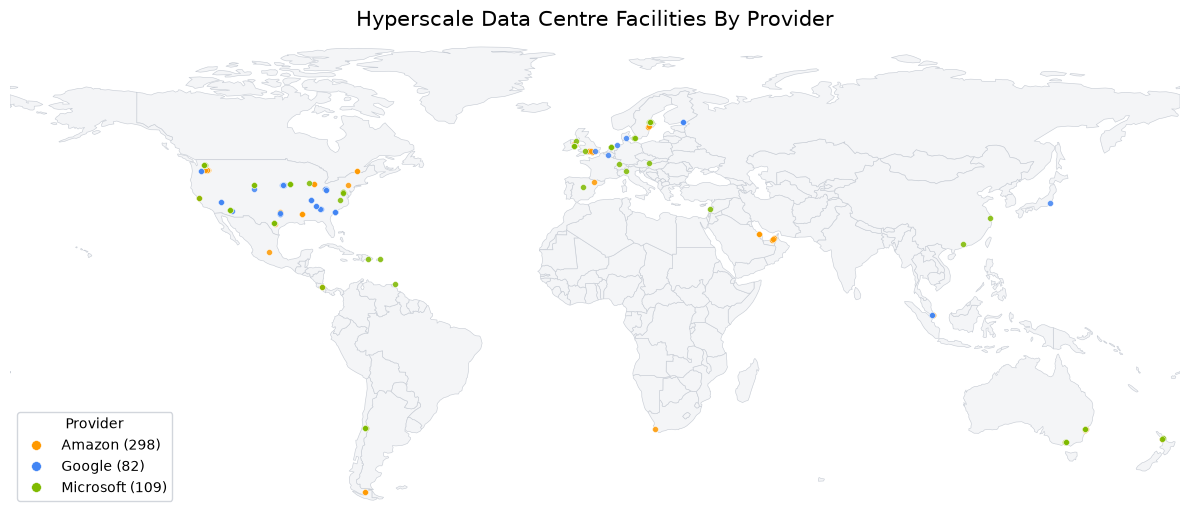

In [9]:
fig = plot_provider_world_map(
    facility_points, world, title="Hyperscale Data Centre Facilities By Provider",
    provider_colors=PROVIDER_COLORS, marker_size=FACILITY_MARKER_SIZE, extent=MAP_EXTENT,
)
fig.savefig(VISUALIZATION_DIR / "facilities_provider_world_map.png", dpi=300, bbox_inches="tight")
display(fig)
plt.close(fig)

## Campuses by provider

Plot the grouped campuses using the same provider colours and geographical extent as the facility map. Save the campus map as a PNG.


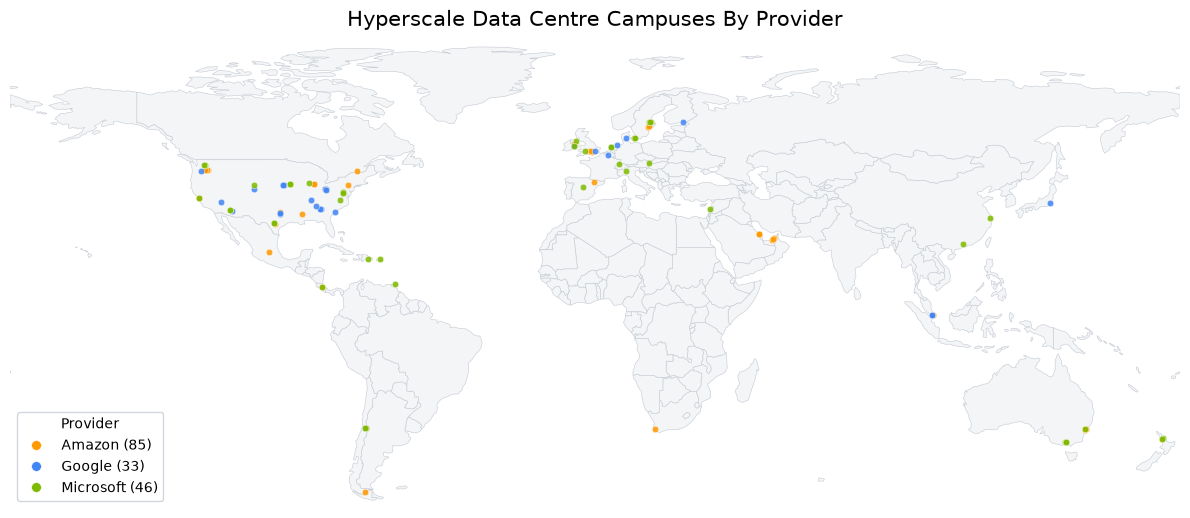

In [10]:
fig = plot_provider_world_map(
    campus_points, world, title="Hyperscale Data Centre Campuses By Provider",
    provider_colors=PROVIDER_COLORS, marker_size=CAMPUS_MARKER_SIZE, extent=MAP_EXTENT,
)
fig.savefig(VISUALIZATION_DIR / "campuses_provider_world_map.png", dpi=300, bbox_inches="tight")
display(fig)
plt.close(fig)